# Environment Setup

## PIP

In [1]:
%pip install colour
%pip install matplotlib
%pip install pandas
%pip install utm
%pip install windrose
%pip install import-ipynb


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note

## Imports

Roll

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


<string>:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
<string>:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


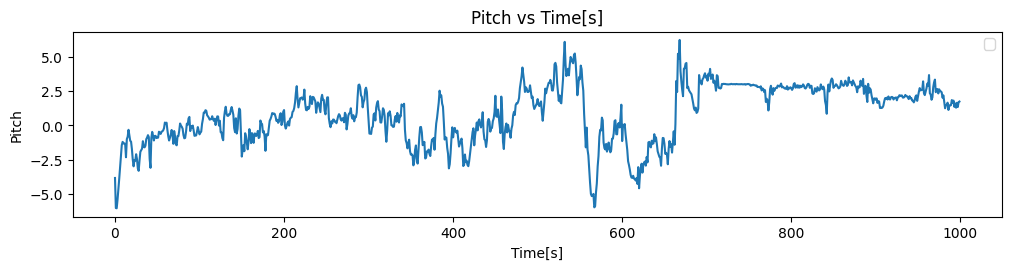

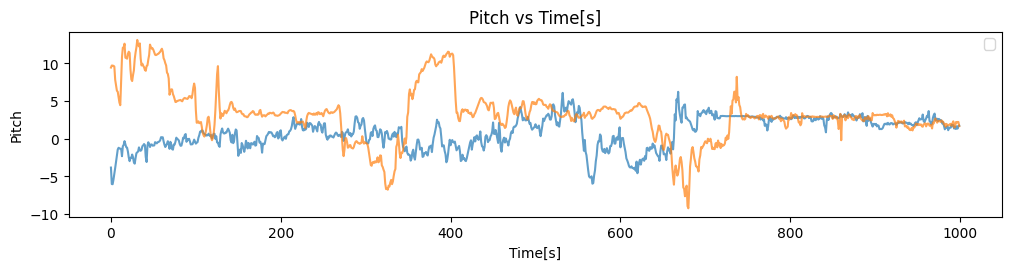

In [2]:

import math
import matplotlib.pyplot as plt
import matplotlib_inline
import numpy as np
import pandas as pd
import utm
from itertools import product
from collections import defaultdict
import io
import pandas as pd
import pickle
import matplotlib.patches as patches
import glob
import os
import datetime
import windrose
from copy import deepcopy
from columnTitles import column
import import_ipynb
from pathlib import Path


from reusablePlots import singlePlot
from reusablePlots import withinGroupPlot
from reusablePlots import betweenGroupPlot
from experimentFileCreation import createExperimentFile

## Functions

In [3]:
def windAnalysis(heading,windDirection, windSpeed):
    newWindDirections = []
    newWindSpeeds = []
    for i in range(0,windDirection.__len__()):
        if(windDirection[i] == 'nan' or heading[i] == 'NaN'):
            a = 1 
        elif(float(windDirection[i]) < 0):
            windScaled = 360+float(windDirection[i])
            windMagnetic = windScaled + float(heading[i])
            if(windMagnetic >= 360):
                windMagnetic = windMagnetic - 360
            newWindDirections.append(float(windMagnetic))
        elif(float(windDirection[i]) > 0):
            windMagnetic = float(windDirection[i]) +float(heading[i])
            if(windMagnetic >= 360):
                windMagnetic = windMagnetic - 360
            newWindDirections.append(float(windMagnetic))

    for i in range(0,windSpeed.__len__()):
        if(windSpeed[i] == 'nan'):
            a = 1 
        elif(float(windSpeed[i]) < 0):
            newWindSpeeds.append(float(windSpeed[i]))
        elif(float(windSpeed[i]) > 0):
            newWindSpeeds.append(float(windSpeed[i]))
        

    ## Calculate Average Wind Direction and Speed and put in a bin
    totalDirection = 0
    totalSpeed = 0
    for i in range(0,newWindDirections.__len__()):
        totalDirection += newWindDirections[i]

    for i in range(0,newWindSpeeds.__len__()):
        totalSpeed += float(newWindSpeeds[i])


    avgDirection = totalDirection/newWindDirections.__len__() 
    avgSpeed = totalSpeed/newWindSpeeds.__len__()
    if math.isnan(avgDirection):
        avgDirection = 0
    return [avgDirection,avgSpeed]

def windBins(dfArray):
    directionBins = [[] for _ in range(361)]
    speedBins = [[] for _ in range(50)]
    for i in range(0,90):
        currdf = dfArray[i]
        if (' WndDr' in currdf) and (' WndSpd' in currdf) and (' HDG' in currdf):
            averages = windAnalysis(currdf[' HDG'],currdf[' WndDr'],currdf[' WndSpd'])
            destinationBin = int(math.floor(averages[0]))
            speedBin = int(math.floor(averages[1]))
            # print(math.floor(averages[0]))
            # print(destinationBin, "--" , i,"speed",speedBin )
            directionBins[destinationBin].append(i)
            speedBins[speedBin].append(i)
    return (directionBins,speedBins)




def summaryStatistics(descent,summaryTarget:str,file,currFlight,descentNum):
    meanDescentRate = np.mean(pd.to_numeric(descent[summaryTarget]))
    medianDescentRate = np.median(pd.to_numeric(descent[summaryTarget]))
    stdDescentRate = np.std(pd.to_numeric(descent[summaryTarget]))
    maxDescentRate = np.max(pd.to_numeric(descent[summaryTarget]))
    minDescentRate = np.min(pd.to_numeric(descent[summaryTarget]))
    results = (float(meanDescentRate), float(medianDescentRate), float(stdDescentRate), float(maxDescentRate), float(minDescentRate))
    file.write("{}, {}, {},{},{},{},{}\n".format(currFlight,descentNum,results[0],results[1],results[2],results[3],results[4]))
    file.flush()


def distanceImageVelocity(descent, convert):

    if ' GndSpd' in descent and ' HDG' in descent:

        index = 0
        for i in range(len(descent)):
            if descent['AltAGL'][i] < 10:
                index = i
                break

        totalX_nm = 0.0
        totalY_nm = 0.0

        for i in range(0, index):

            s1 = float(descent[' GndSpd'][i])
            s2 = float(descent[' GndSpd'][i+1])

            if convert:
                s1 *= 1.94384
                s2 *= 1.94384

            avgS = (s1 + s2) / 2

            heading_deg = float(descent[' HDG'][i])
            heading_rad = math.radians(heading_deg)

            d_nm = avgS / 3600.0

            dx = d_nm * math.cos(heading_rad)
            dy = d_nm * math.sin(heading_rad)

            totalX_nm += dx
            totalY_nm += dy

        # Distance (magnitude)
        distance_nm = math.sqrt(totalX_nm**2 + totalY_nm**2)

        # Direction (bearing)
        bearing_rad = math.atan2(totalY_nm, totalX_nm)
        bearing_deg = (math.degrees(bearing_rad) + 360) % 360

        print("Distance:", distance_nm, "NM")
        print("Bearing:", bearing_deg, "deg")

        return [distance_nm, bearing_deg]
    

def utilizeModelData(useManual:bool = False):
    filePath = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/FollowCoords2--Turbulence Experiments 2026-02-14 14:10:32.404221"
    filePath2 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/Roll1--Turbulence Experiments 2026-02-13 13:03:32.478263/1_Roll1--Turbulence Experiments.csv"
    filePath3 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/RecTest1--Turbulence Experiments 2026-03-20 09:53:39.848992/{}_RecTest1--Turbulence Experiments.csv"
    filePath4 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/RecTest2--Turbulence Experiments 2026-03-20 09:59:21.064022/{}_RecTest2--Turbulence Experiments.csv"
    filePath5 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/RecTest3--Turbulence Experiments 2026-03-20 10:09:38.439818/{}_RecTest3--Turbulence Experiments.csv"
    filePath6 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/RecTest4--Turbulence Experiments 2026-03-20 10:16:14.758129/{}_RecTest4--Turbulence Experiments.csv"
    showcaseRun = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/RecTest6--Turbulence Experiments 2026-03-20 10:32:46.050711/{}_RecTest6--Turbulence Experiments.csv"
    showcaseRun2= "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/RecTest7--Turbulence Experiments 2026-03-20 10:36:47.246532/{}_RecTest7--Turbulence Experiments.csv"
    comparisonRuns = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/ComparisonRuns--Turbulence Experiments 2026-03-13 17:00:07.067204/{}_ComparisonRuns--Turbulence Experiments.csv"
    ex2 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/ex2--turbulence experiments 2026-04-13 01:20:57.181772/{}_ex2--turbulence experiments.csv"
    ex6 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/Ex6--turbulence experiments 2026-04-13 13:00:40.017013/{}_Ex6--turbulence experiments.csv"
    combinedAnalysis = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/CombinedAnalysis--turbulence experiments 2026-06-05 10:05:24.166731/{}_CombinedAnalysis--turbulence experiments.csv"
    manualControl1 = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/ManualControl-1--turbulence experiments 2026-04-23 16:20:19.558488/{}_ManualControl-1--turbulence experiments.csv"
    modelData = [[]]
    for x in range (1,100):
        try:
            # data = pd.read_csv('/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/ComparisonRuns--Turbulence Experiments 2026-03-13 17:00:07.067204/{}_ComparisonRuns--Turbulence Experiments.csv'.format(x))
            # data = pd.read_csv(comparisonRuns.format(x))
            # data = pd.read_csv(showcaseRun.format(x))
            data = pd.read_csv(ex6.format(x))
            if (useManual):
                data = pd.read_csv(manualControl1.format(x))

            modelData[0].append(data)
        except FileNotFoundError:
            print("{} Files Loaded".format(x-1))
            return modelData
            break
        else:
            # Continue Loop
            continue


## Global Variables

In [4]:
directionBins = [[] for _ in range(361)]
speedBins = [[] for _ in range(50)]
colors =["red","green","blue","purple","orange","black","yellow","cyan","magenta","brown","pink","gray","olive","lime","teal","navy"]

# Transformations

In [5]:
def loadData(file,folder,fileType):
    dataArray = []
    folder_path = Path(folder)
    for file_path in folder_path.glob("*.csv"):
        df = pd.read_csv(f'{file_path}')
        df.columns = df.columns.str.lstrip()
        df = df.replace(r'^\s*$', np.nan, regex=True)
        df = df.astype('float')
        dataArray.append(df)
    return dataArray

# modelDataArray = loadData("{}_NewLogTest--turbulence experiments",
#                           "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/NewLogTest--turbulence experiments 2026-08-12 12:49:29.442596/",
#                           ".csv")
modelDataArray = loadData("{}_PaperDraft--turbulence experiments",
         "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Data_Storage/PaperDraft--turbulence experiments 2026-08-12 17:41:36.843847",
         ".csv")
gatsDataArray = loadData("Cessna_172S_flight_{}",
                          "../../Project_Data/Empirical_Data/GATS_Dataset/",
                          ".csv")

/var/folders/mg/0046pj397qn7zqxn7sxp4b_w0000gn/T/ipykernel_74679/1515094139.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(r'^\s*$', np.nan, regex=True)
/var/folders/mg/0046pj397qn7zqxn7sxp4b_w0000gn/T/ipykernel_74679/1515094139.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(r'^\s*$', np.nan, regex=True)
/var/folders/mg/0046pj397qn7zqxn7sxp4b_w0000gn/T/ipykernel_74679/1515094139.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To

In [6]:
def checkExcluded(x1,x2,excludedDescents):
    for descent in excludedDescents:
        if(x1>= descent[0] and x1 <= descent[1] 
           or
           x2>= descent[0] and x2 <= descent[1]
           or descent[0]>= x1 and descent[0] <= x2 and descent[1]>= x1 and descent[1] <= x2):
            return True
    return False

def identifyChange(dataframe, column, changeThreshold:int = 800, minStep:int = 10, maxStep:int = 50,startUpperBound:int = 1000000,startLowerBound:int = 0,stopUpperBound:int = 1000000,stopLowerBound:int=0):
    changeWindowArray = []
    excludedChangeWindow = []
    for stepCount in range(minStep,maxStep):
        step = stepCount
        for xInner in range(0, dataframe.__len__()-step, step):
            storageCount = 0
            x1 = xInner
            x2 = xInner+step
            value1 = float(dataframe[column].iloc[x1])
            value2 = float(dataframe[column].iloc[x2])
            delta = value1 - value2
            if delta >= changeThreshold and (value2 <= stopUpperBound and value2 >= stopLowerBound) and (value1 <= startUpperBound and value1 > startLowerBound):
                # print(f"Found Descent in flight {x}: From {currdf['AltAGL'][x1]} ft AGL to {currdf['AltAGL'][x2]} ft AGL over {x2-x1} data points.")
                # if(dataframe[column][x1] <= 1020 and dataframe[column][x1] >=0):
                if(True):
                    # print(f"Found Change Window on column {column}: From {dataframe[column][x1]} ft AGL to {dataframe[column][x2]} ft AGL over {x2-x1} data points.")
                    excludeWindow = checkExcluded(x1,x2,excludedChangeWindow)
                    if(excludeWindow):
                        ## Do Nothing 
                        print("descent excluded: {} to {}".format(x1,x2))
                        a=1
                    elif(not excludeWindow):
                        # newDataFrame = pd.DataFrame(dataframe[:][x1:x2]).reset_index()
                        newDataFrame = dataframe.iloc[x1:x2].copy().reset_index(drop=True)
                        changeWindowArray.append(newDataFrame)
                        excludedChangeWindow.append([x1,x2])
                        print("Window added to exclusion between: {} to {}".format(x1,x2))
                    storageCount+=1
    return changeWindowArray


def alignOnCondition(dataframeArray,column,matchingValue,tolerance):
    newArray = []
    for df in dataframeArray:
        for x in range(0,df.__len__()):
            if float(df[column].iloc[x]) <= matchingValue+tolerance and float(df[column].iloc[x]) >= matchingValue-tolerance:
                #Align this as new 0 index,
                df.index = range(-x, len(df) - x)
                #Exit For-Loop for this condition, move to next dataframe
                newArray.append(df)
                break
    return newArray

Window added to exclusion between: 0 to 135
descent excluded: 0 to 136
descent excluded: 0 to 137
descent excluded: 0 to 138
descent excluded: 0 to 139
descent excluded: 0 to 140
Window added to exclusion between: 0 to 127
descent excluded: 0 to 128
descent excluded: 0 to 129
descent excluded: 0 to 130
descent excluded: 0 to 131
descent excluded: 0 to 132
descent excluded: 0 to 133
descent excluded: 0 to 134
descent excluded: 0 to 135
Window added to exclusion between: 0 to 106
descent excluded: 0 to 107
descent excluded: 0 to 108
descent excluded: 0 to 109
descent excluded: 0 to 110
descent excluded: 0 to 111
descent excluded: 0 to 112
descent excluded: 0 to 113
descent excluded: 0 to 114
descent excluded: 0 to 115
descent excluded: 0 to 116
Window added to exclusion between: 0 to 100
descent excluded: 0 to 101
descent excluded: 0 to 102
descent excluded: 0 to 103
descent excluded: 0 to 104
descent excluded: 0 to 105
descent excluded: 0 to 106
descent excluded: 0 to 107
descent exclud

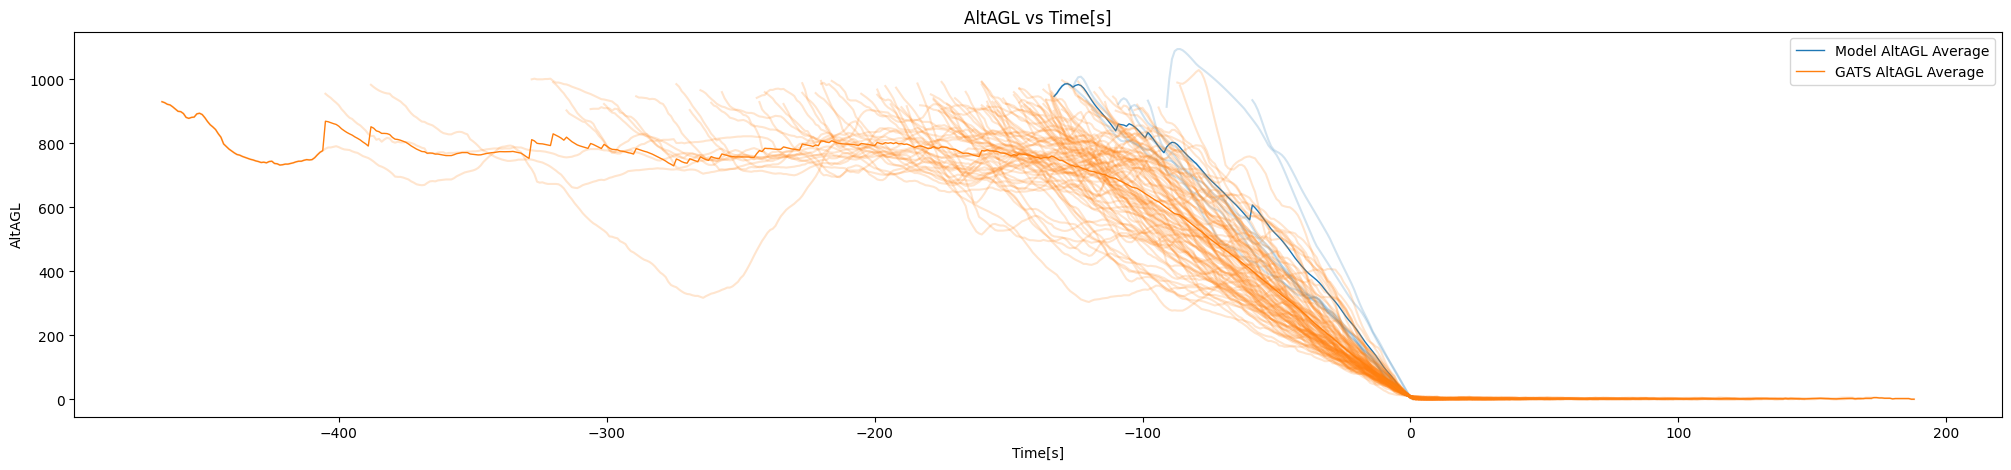

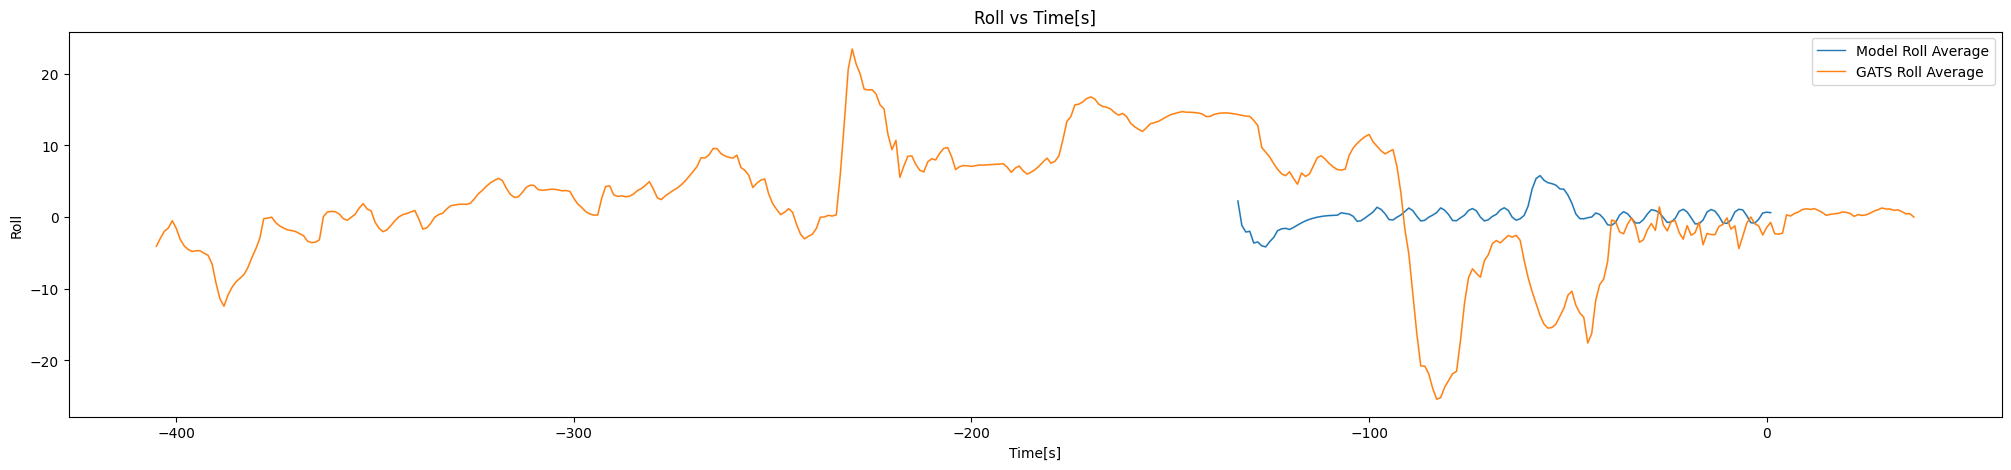

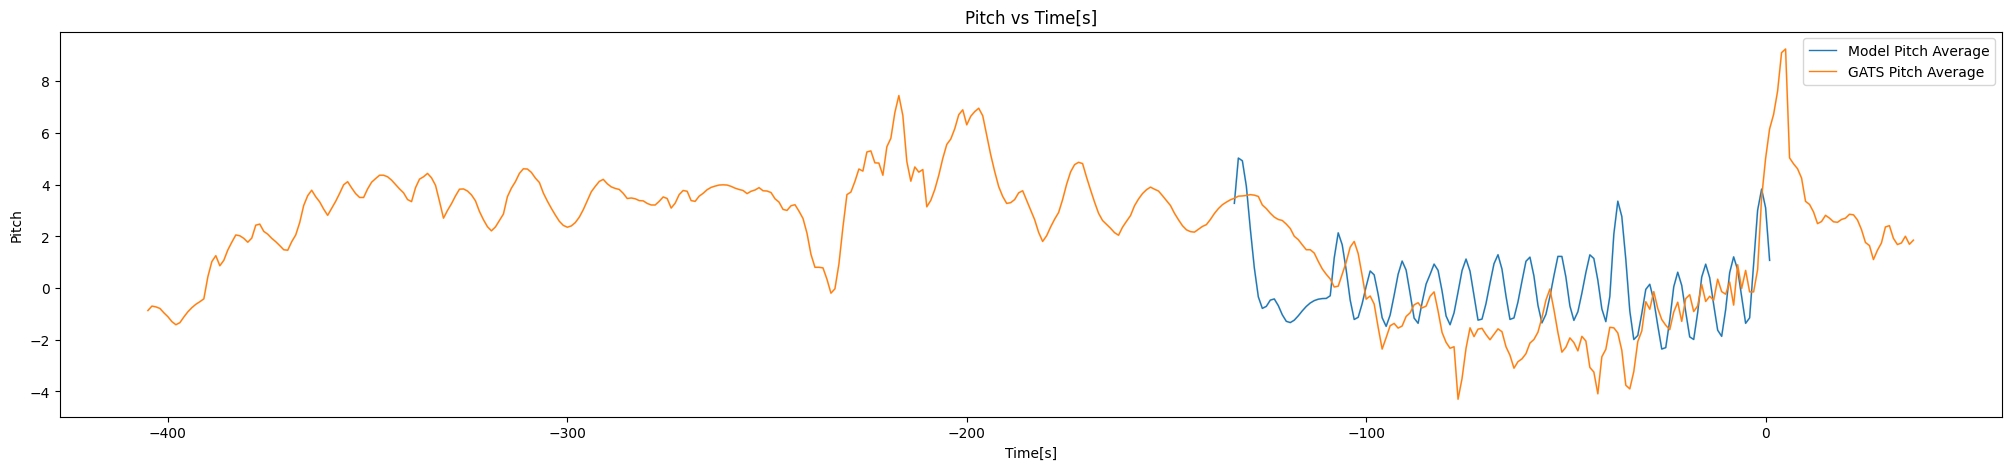

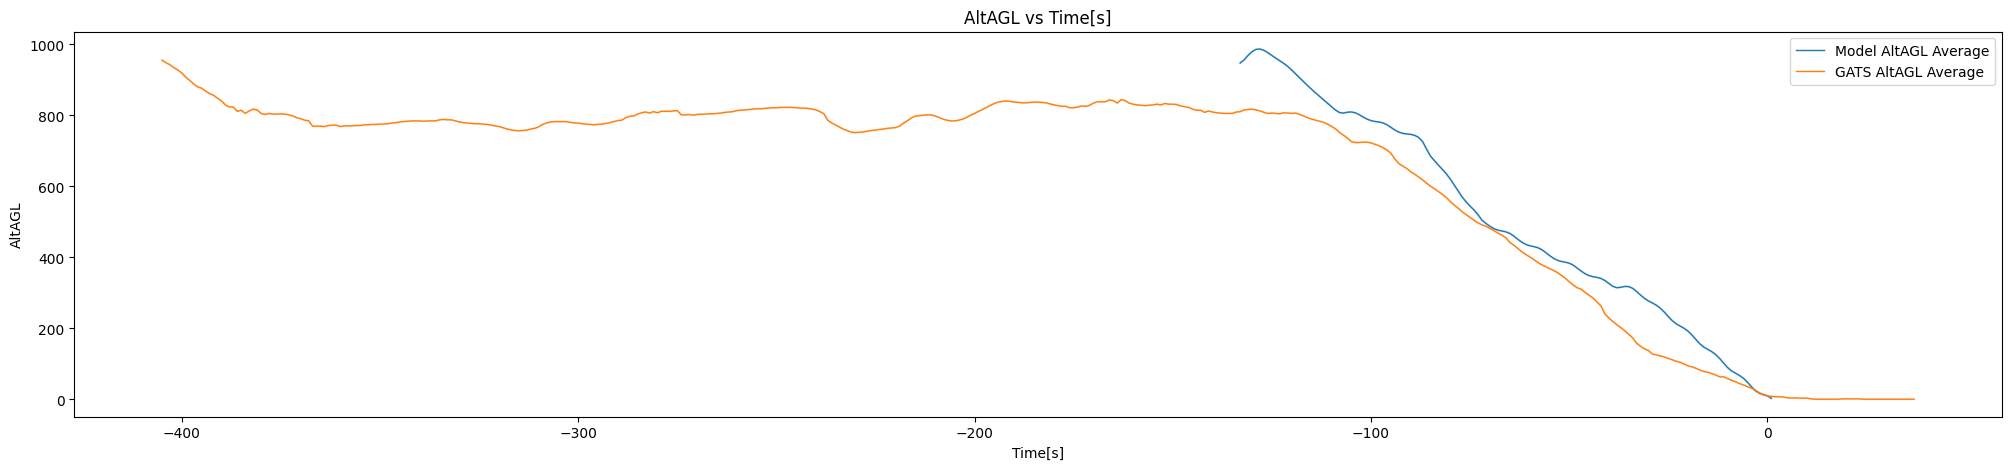

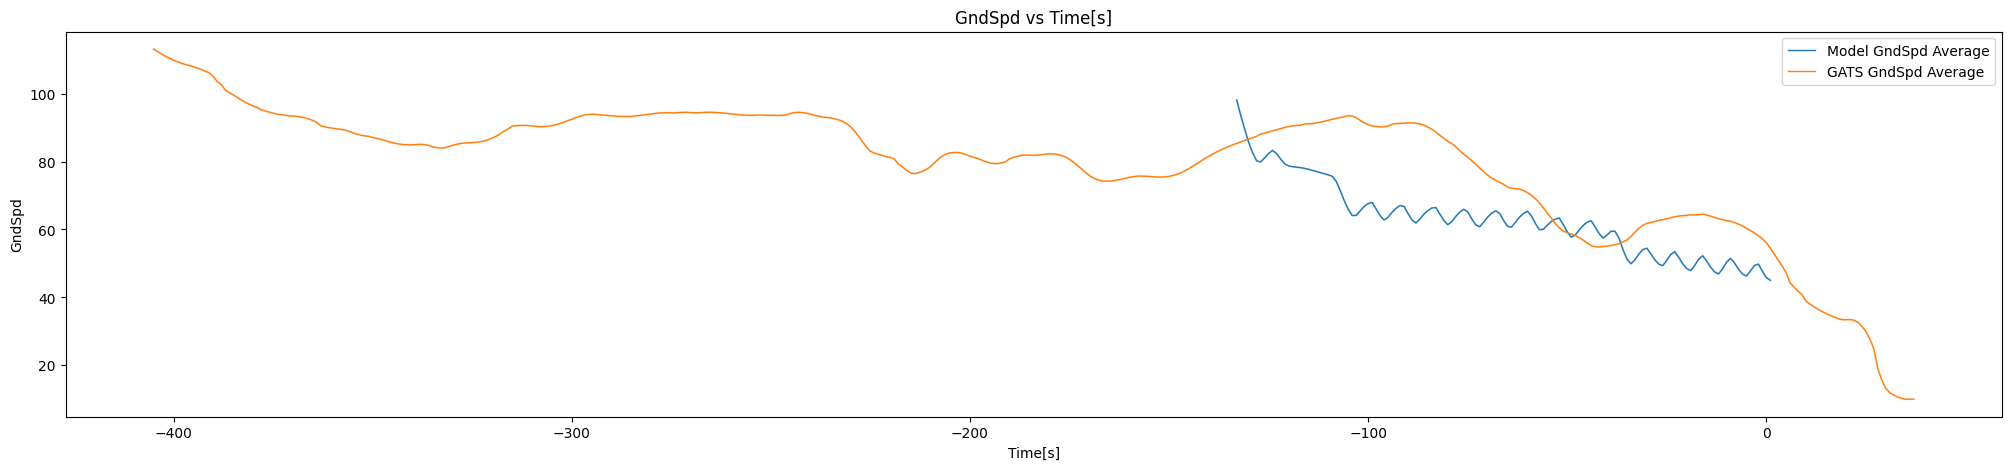

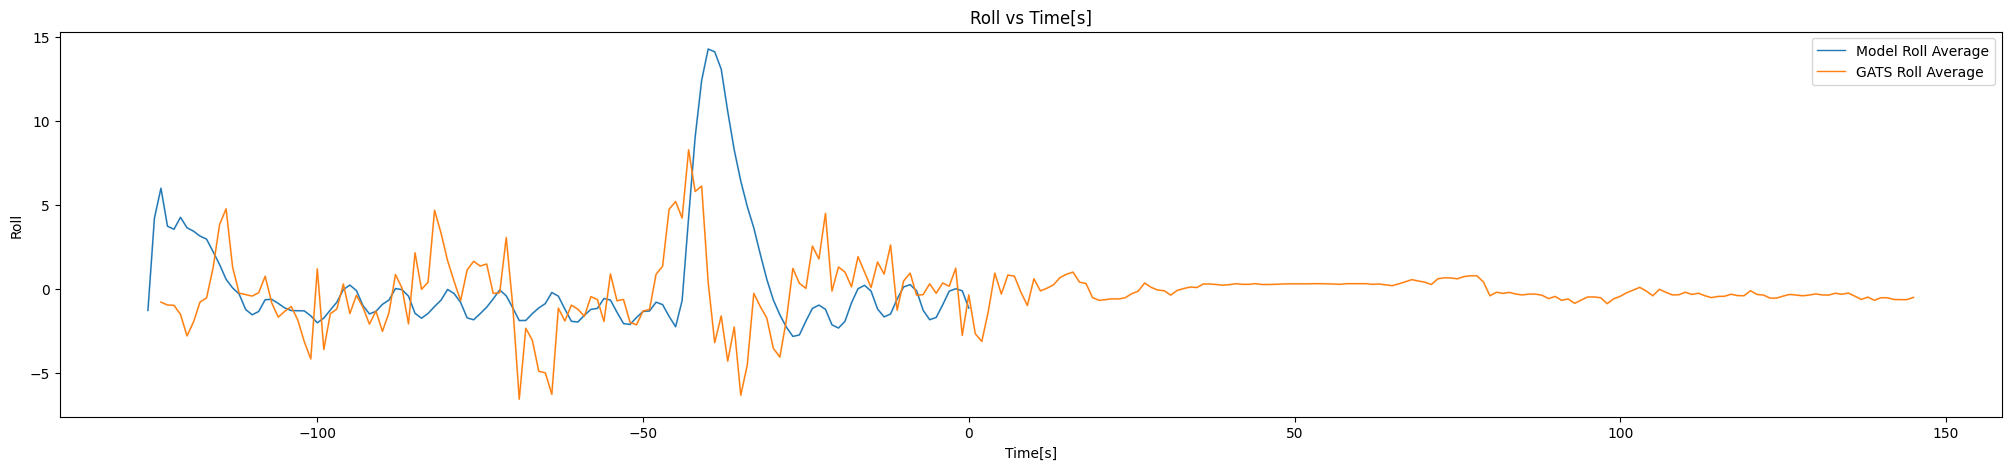

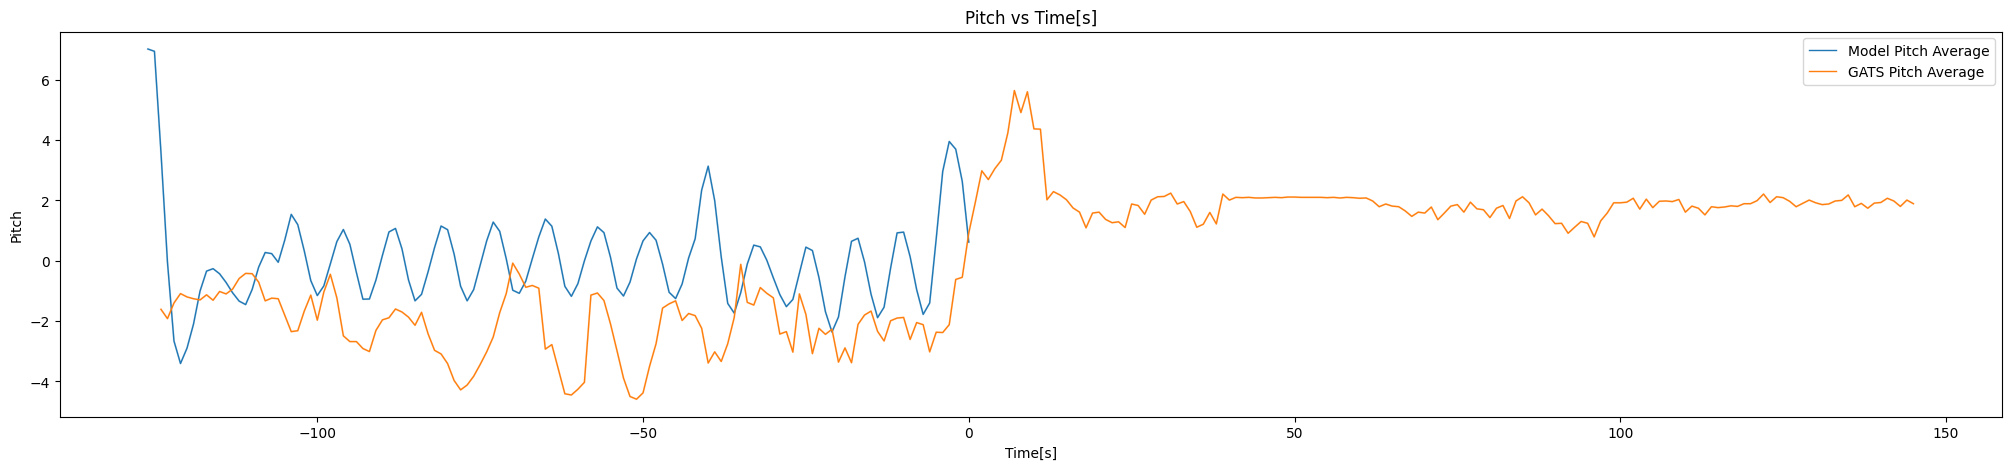

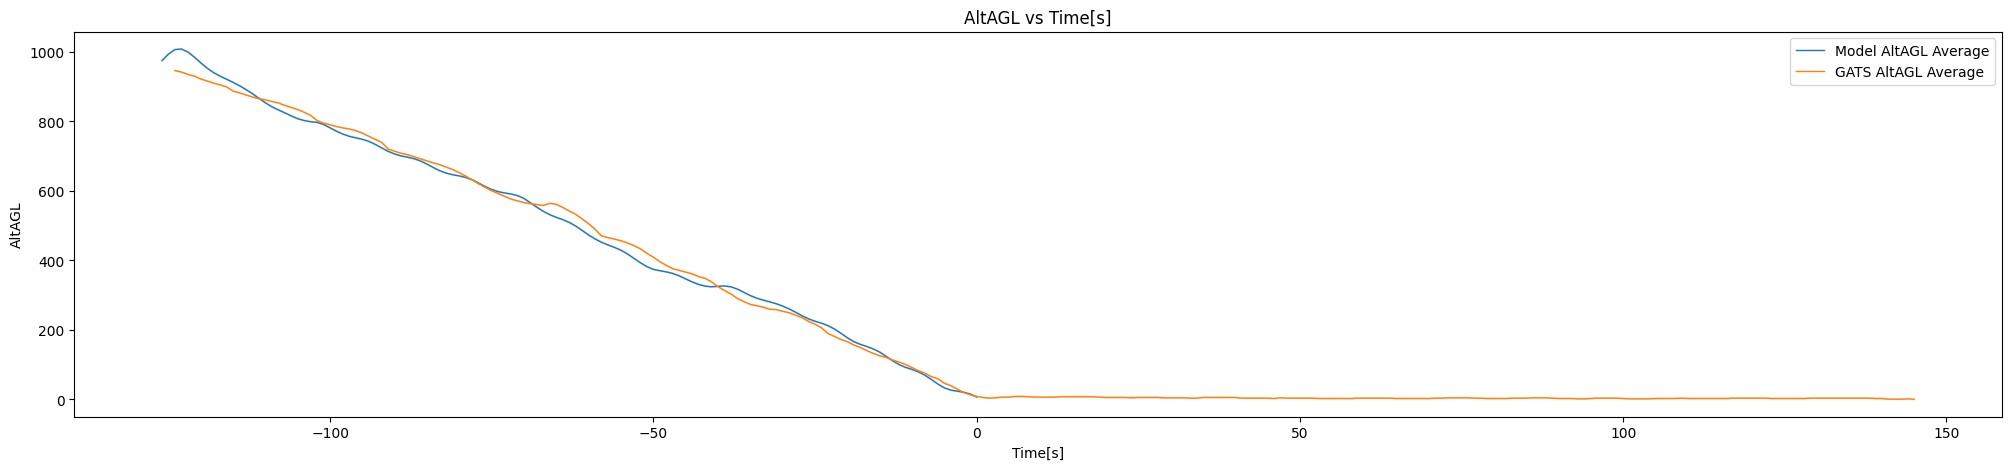

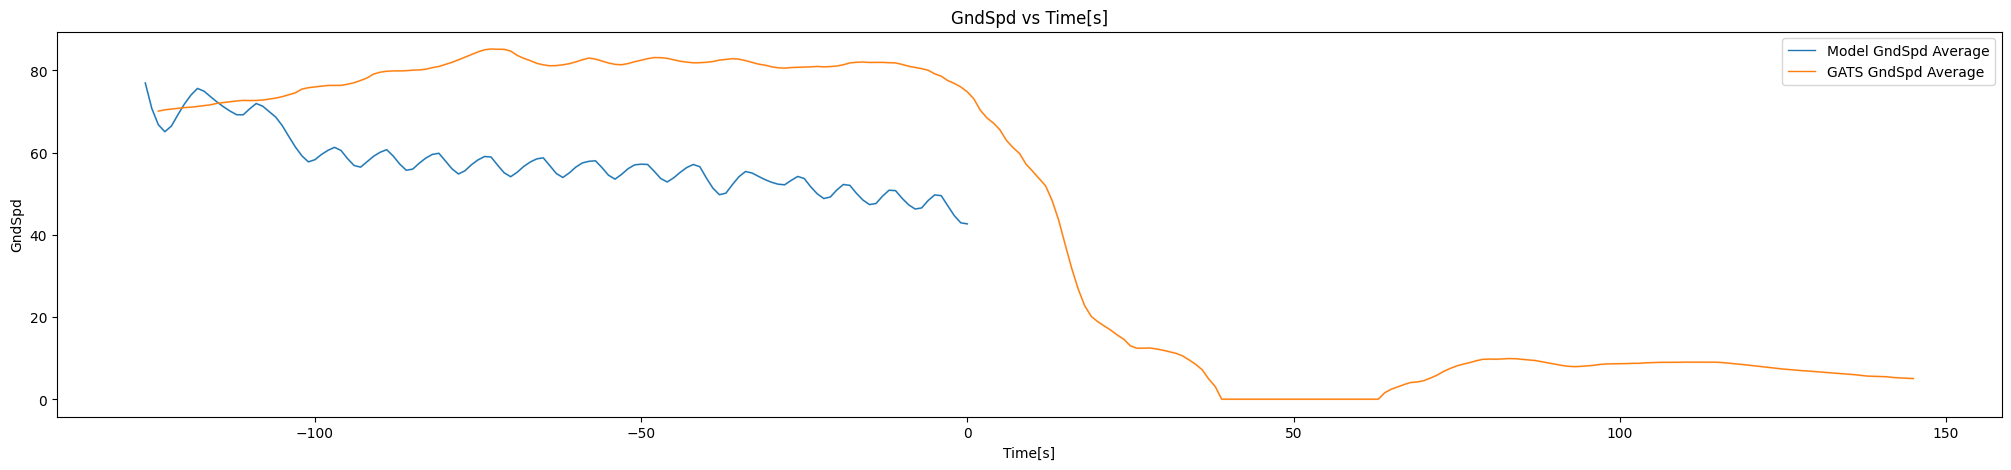

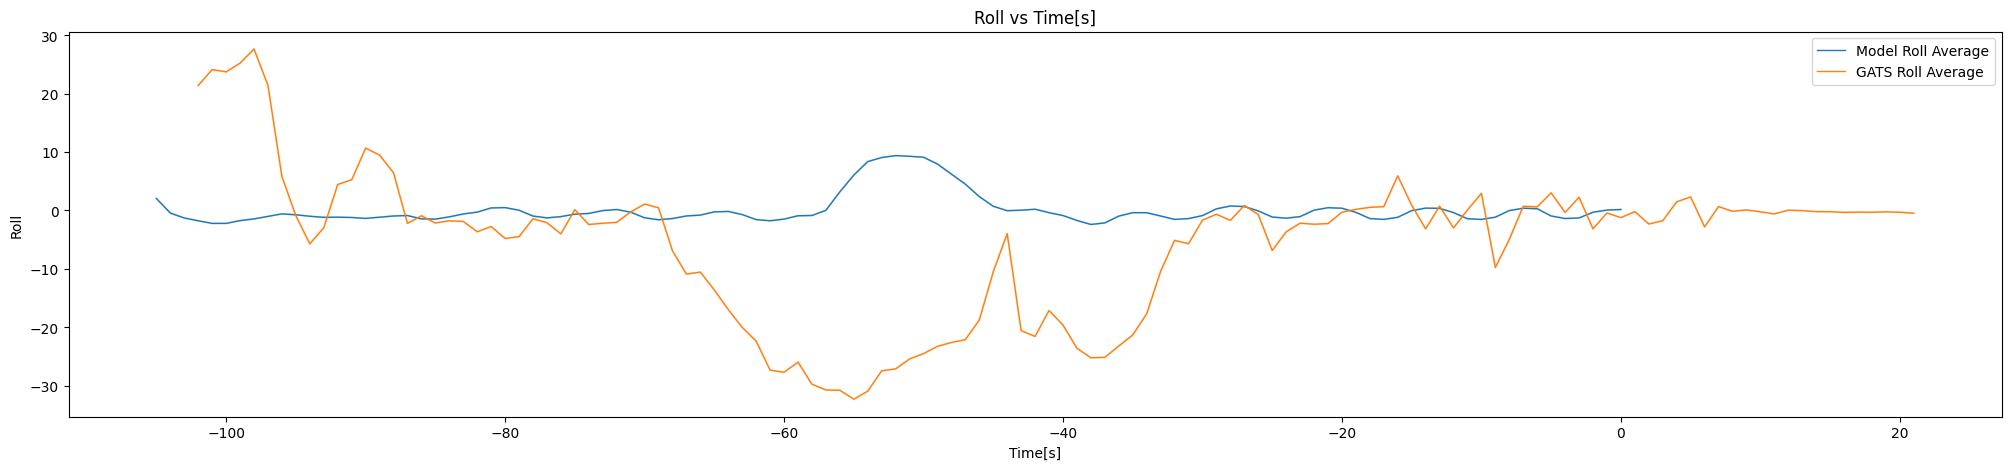

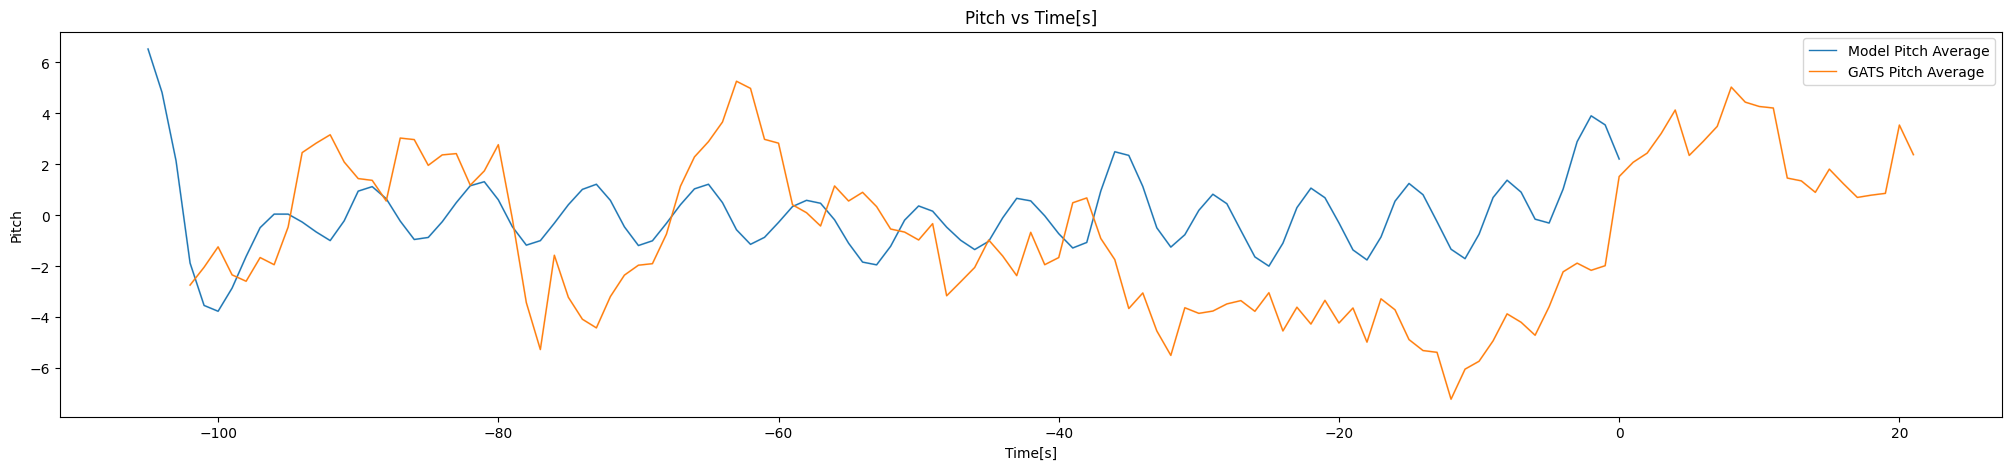

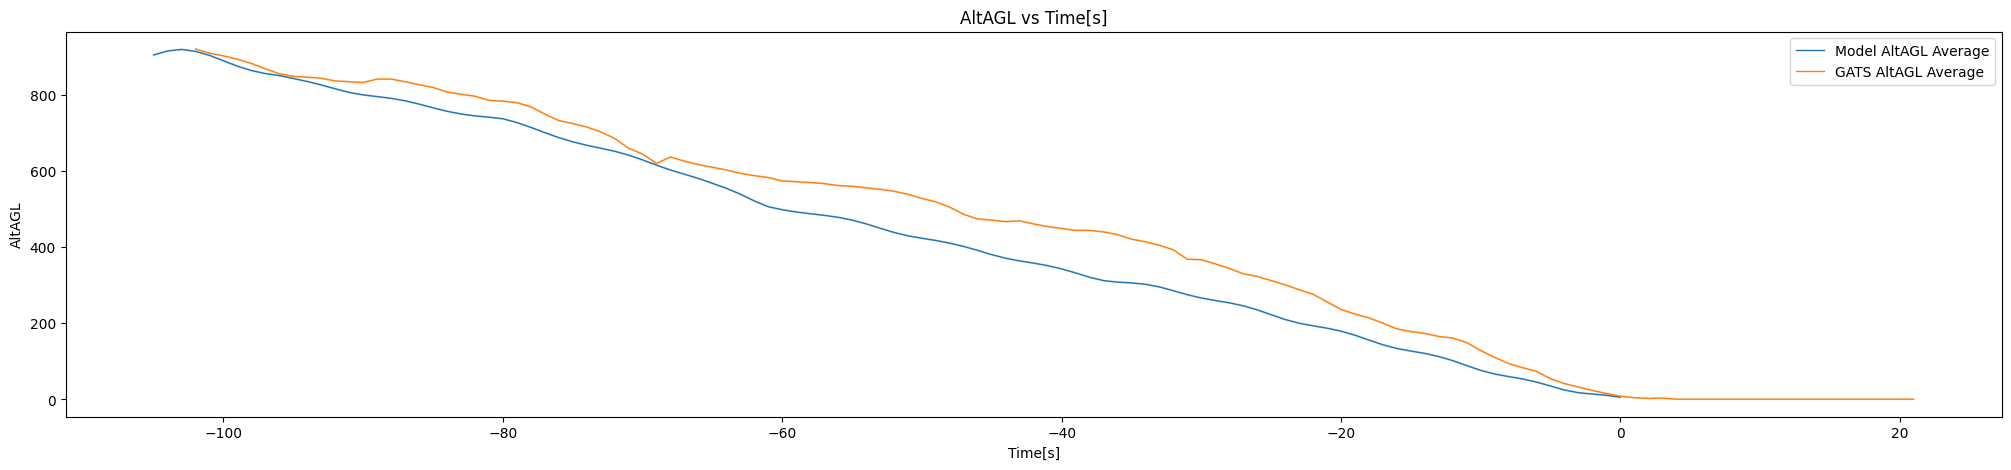

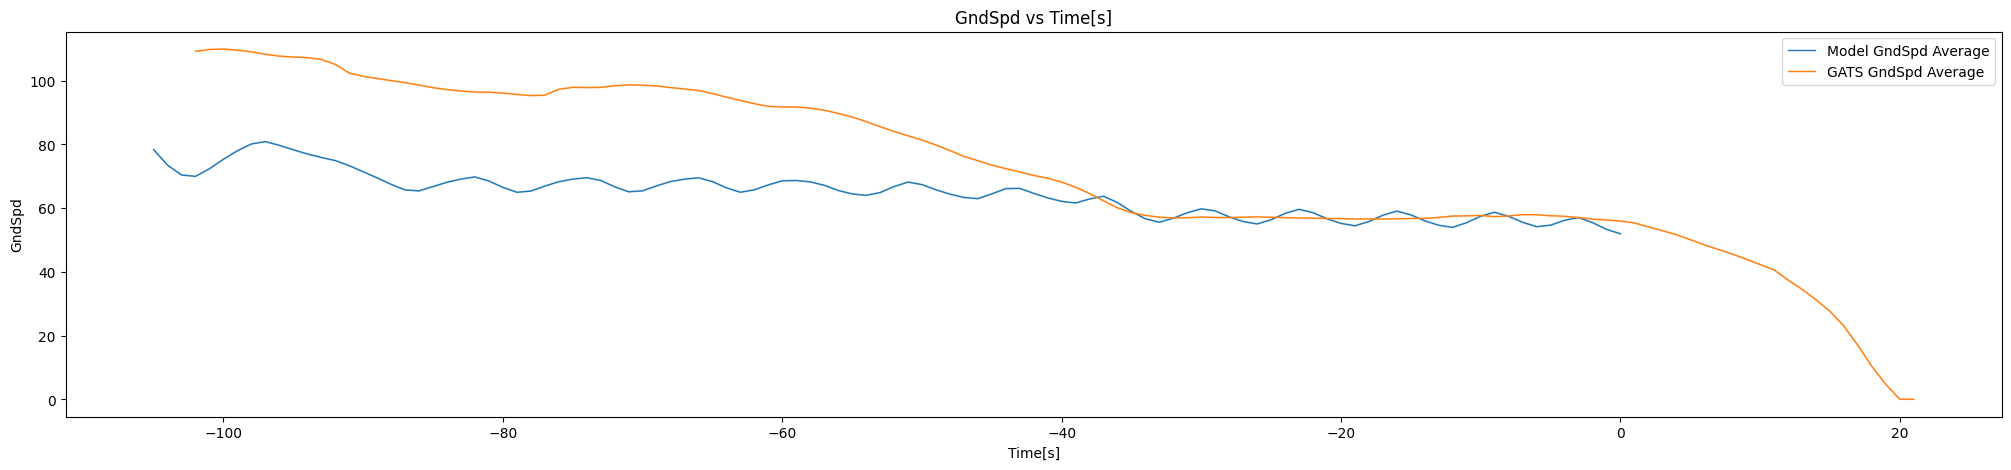

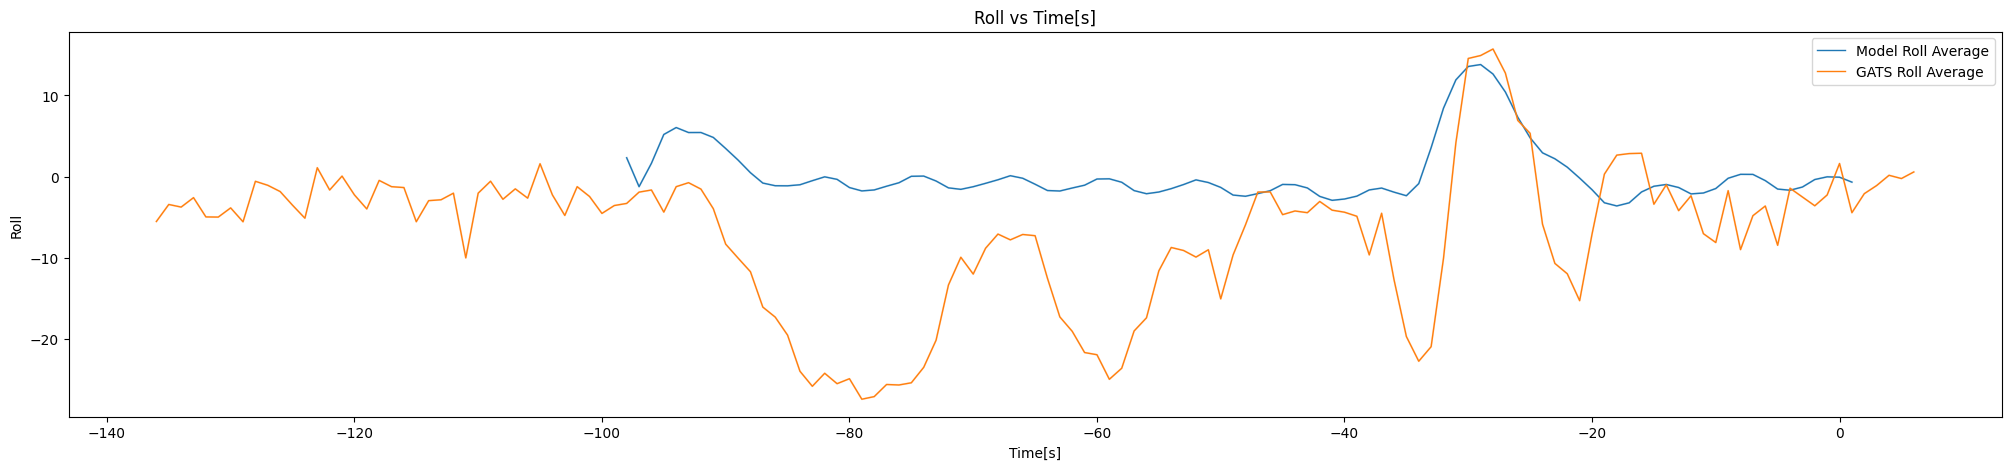

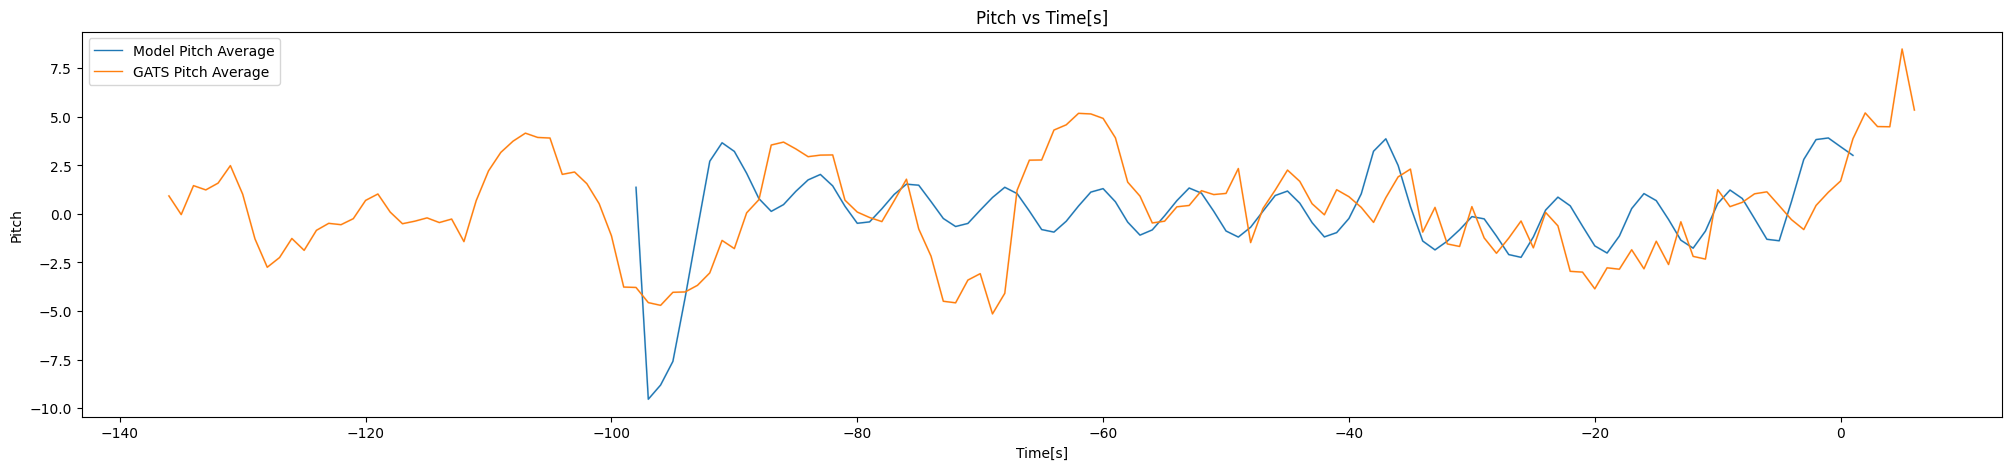

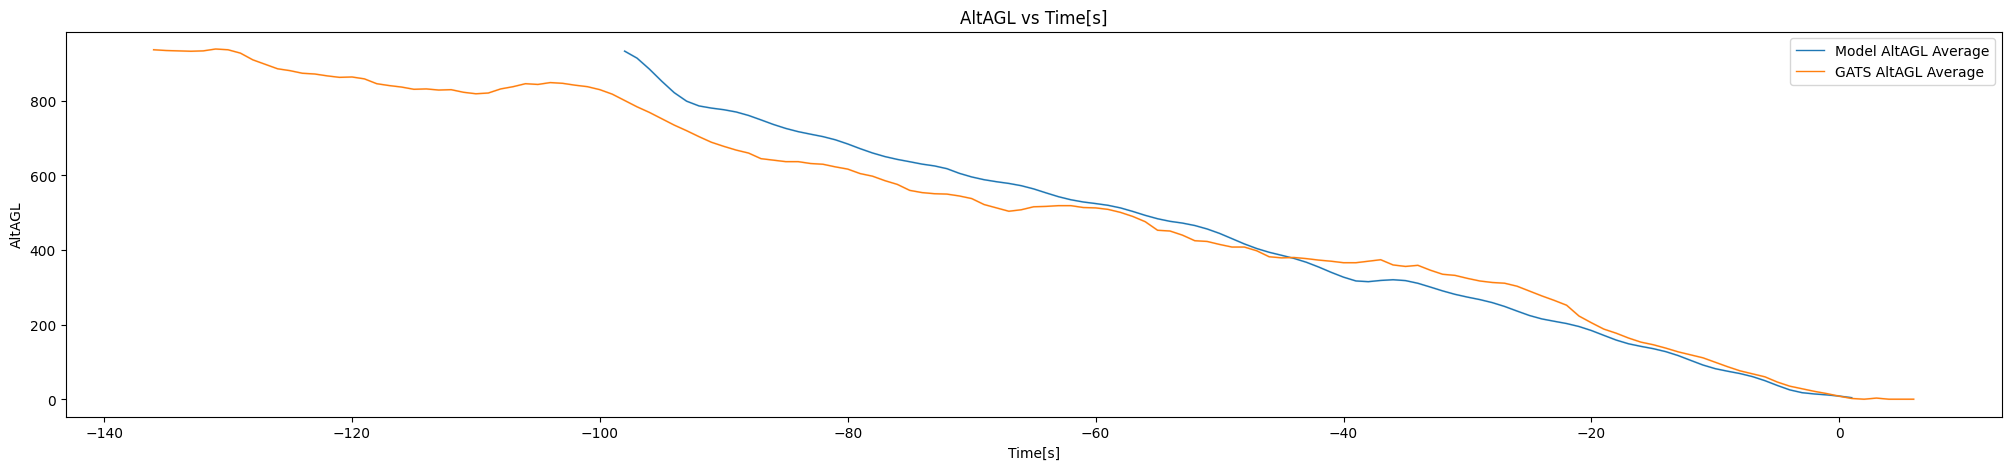

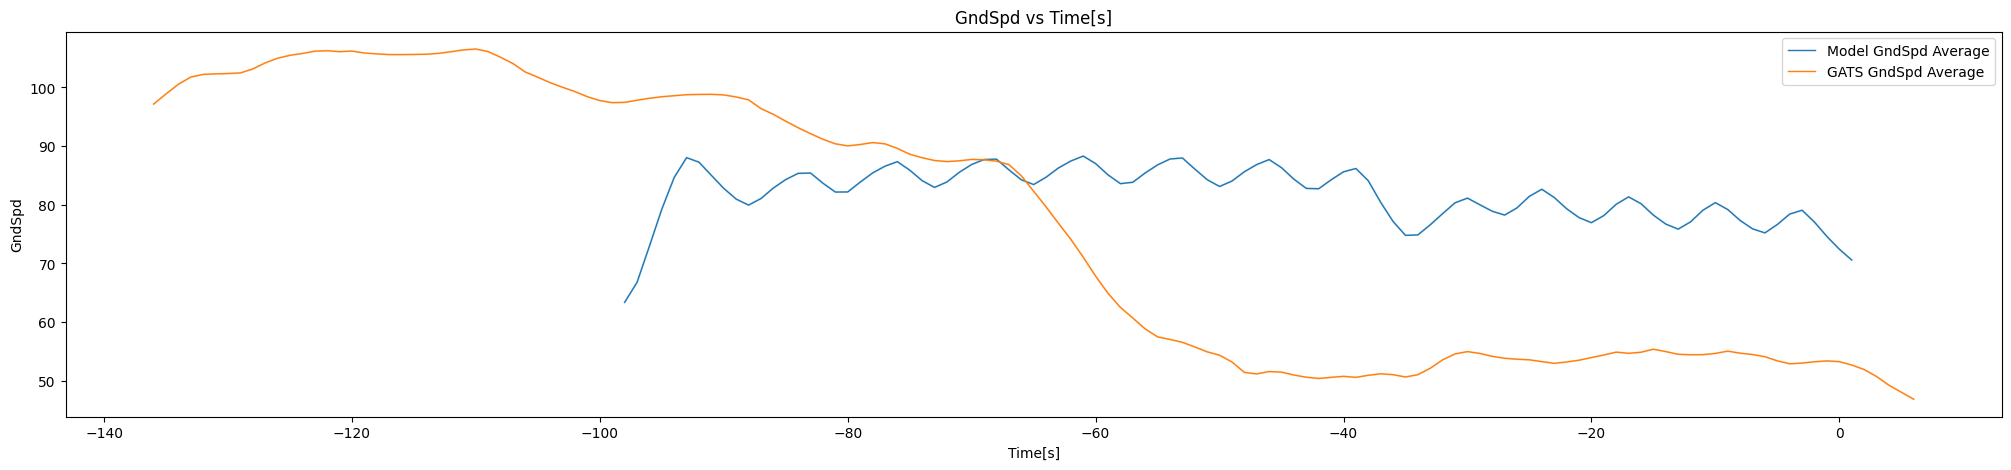

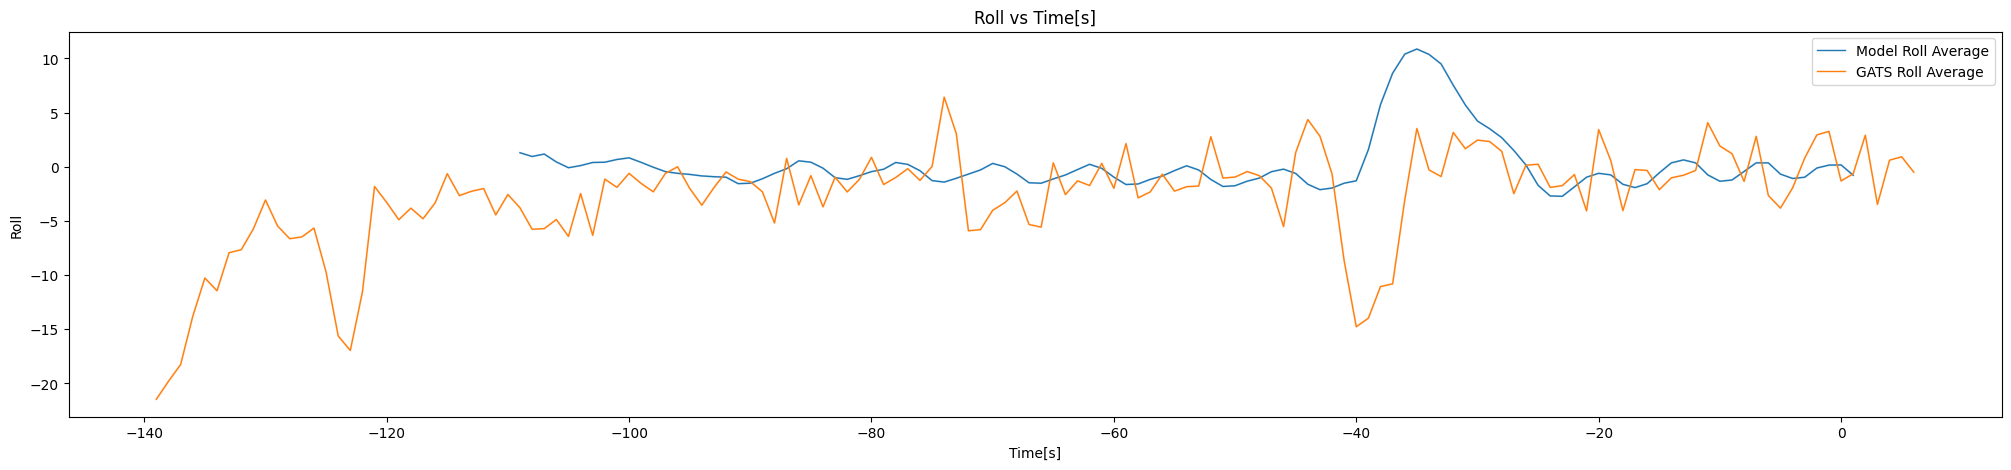

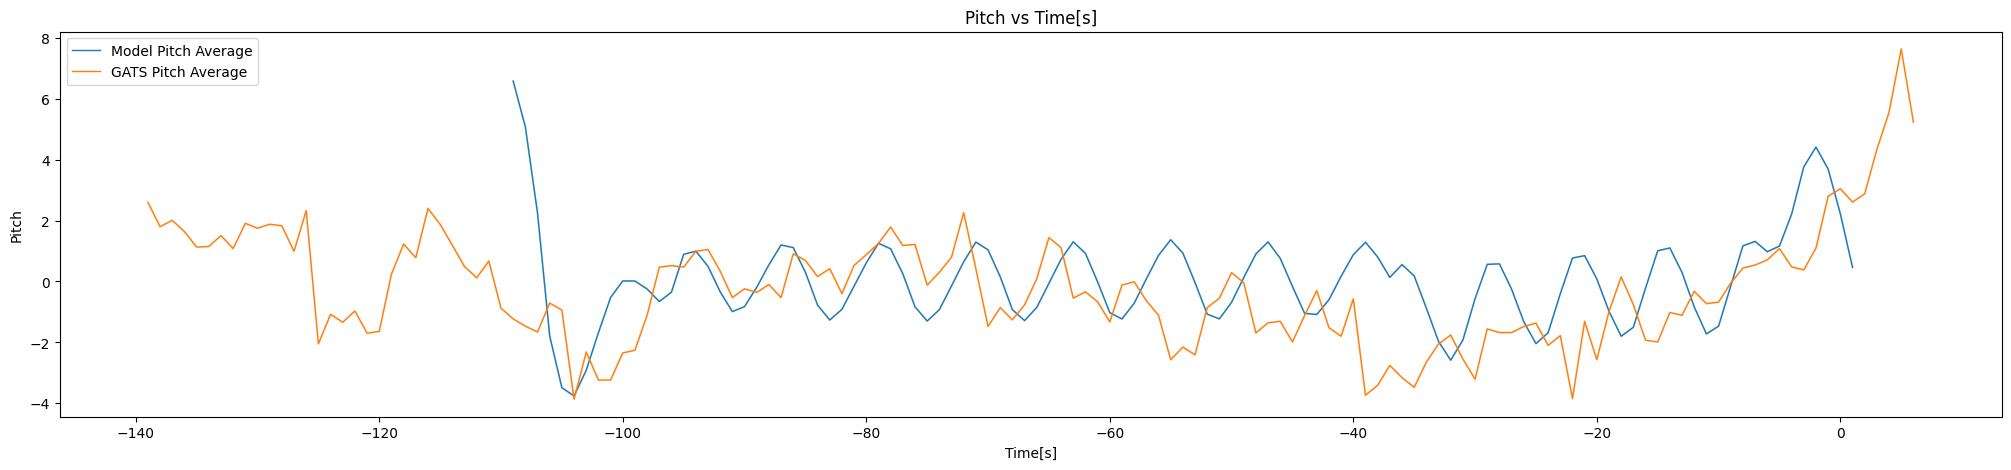

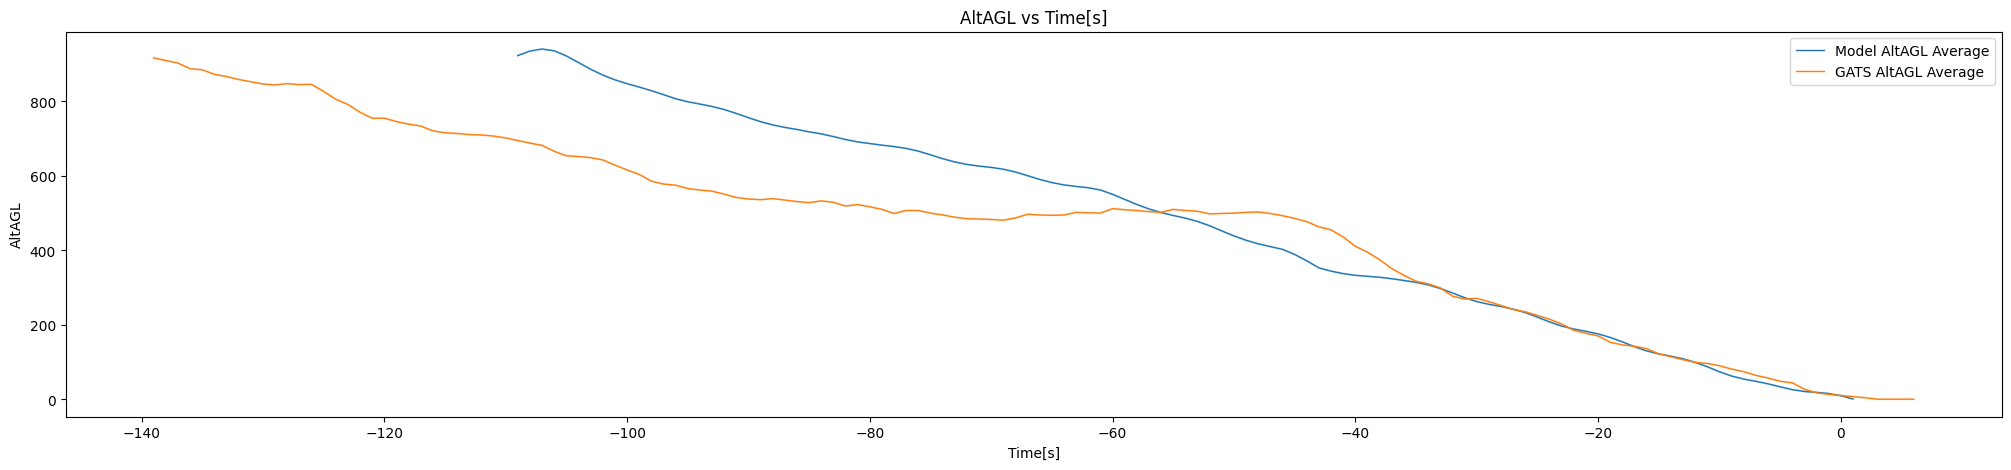

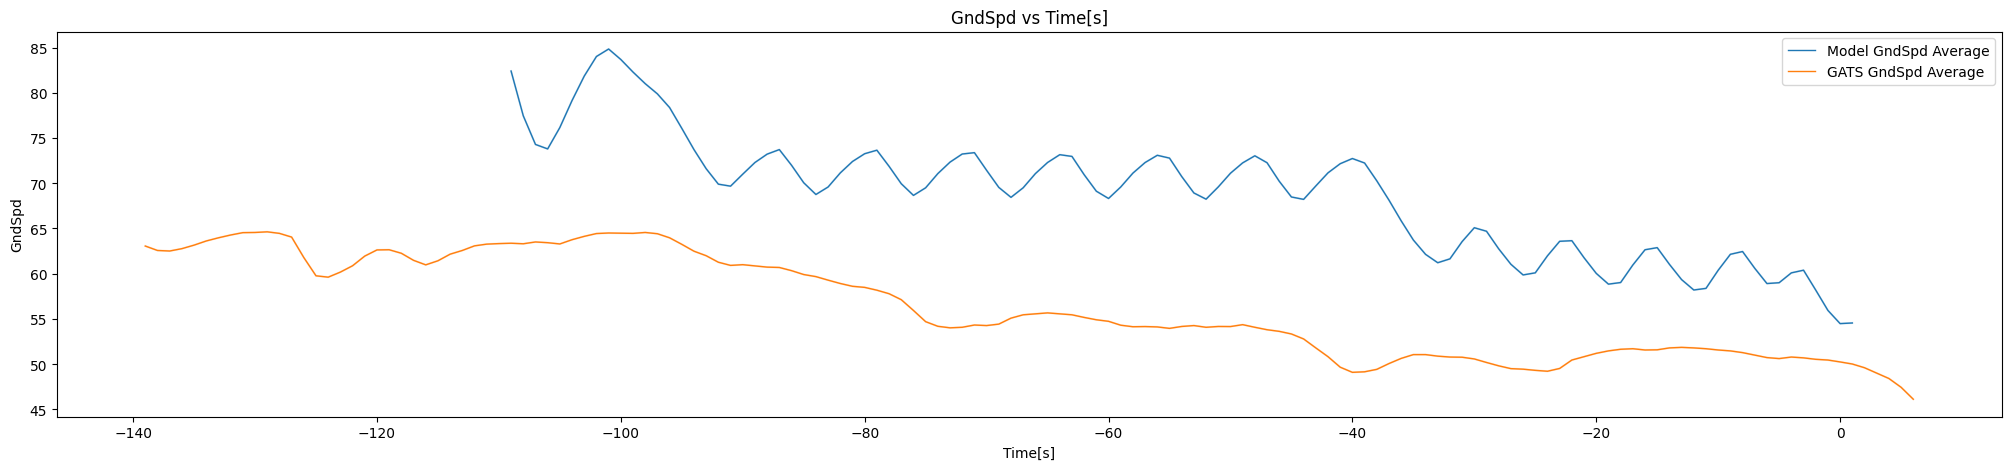

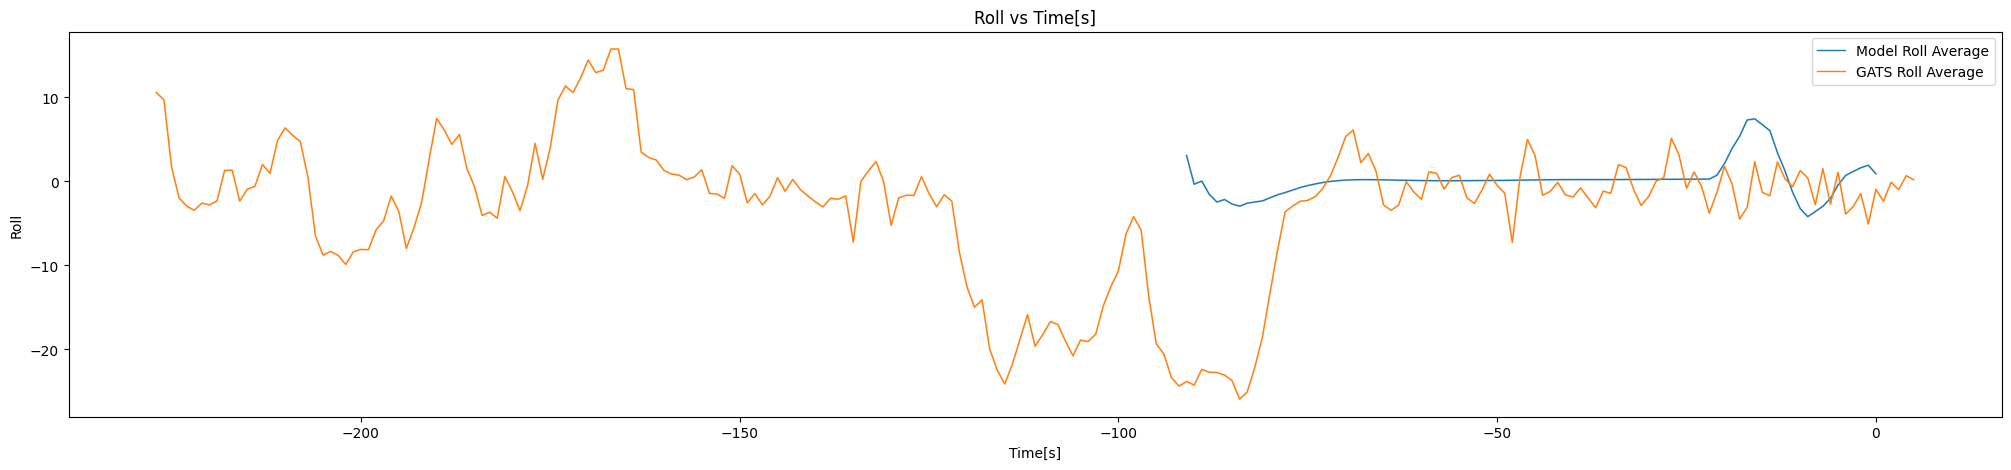

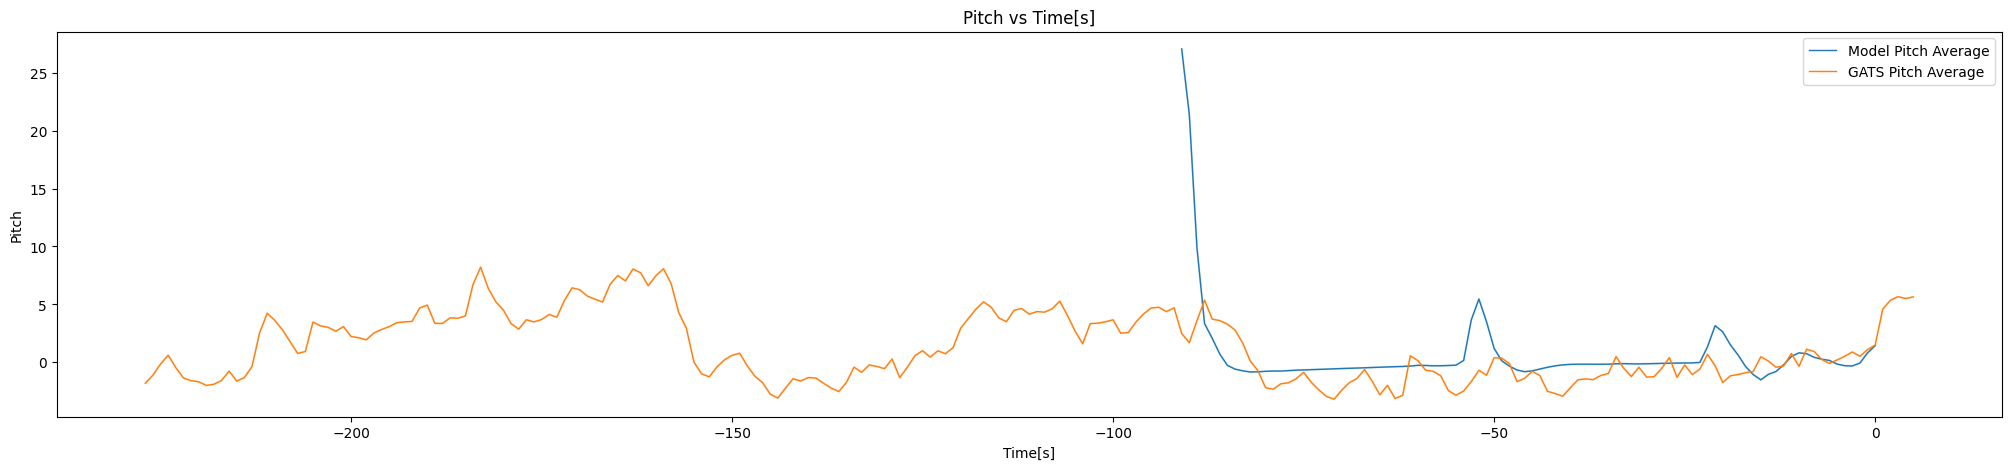

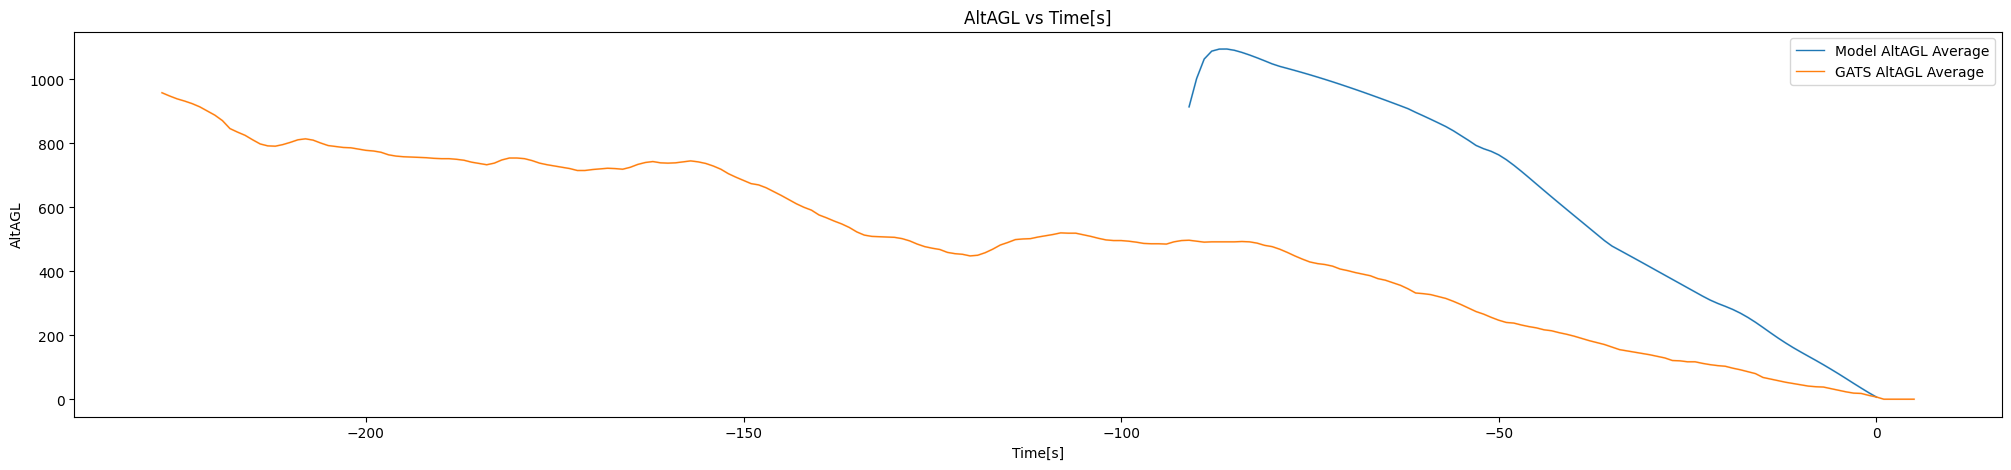

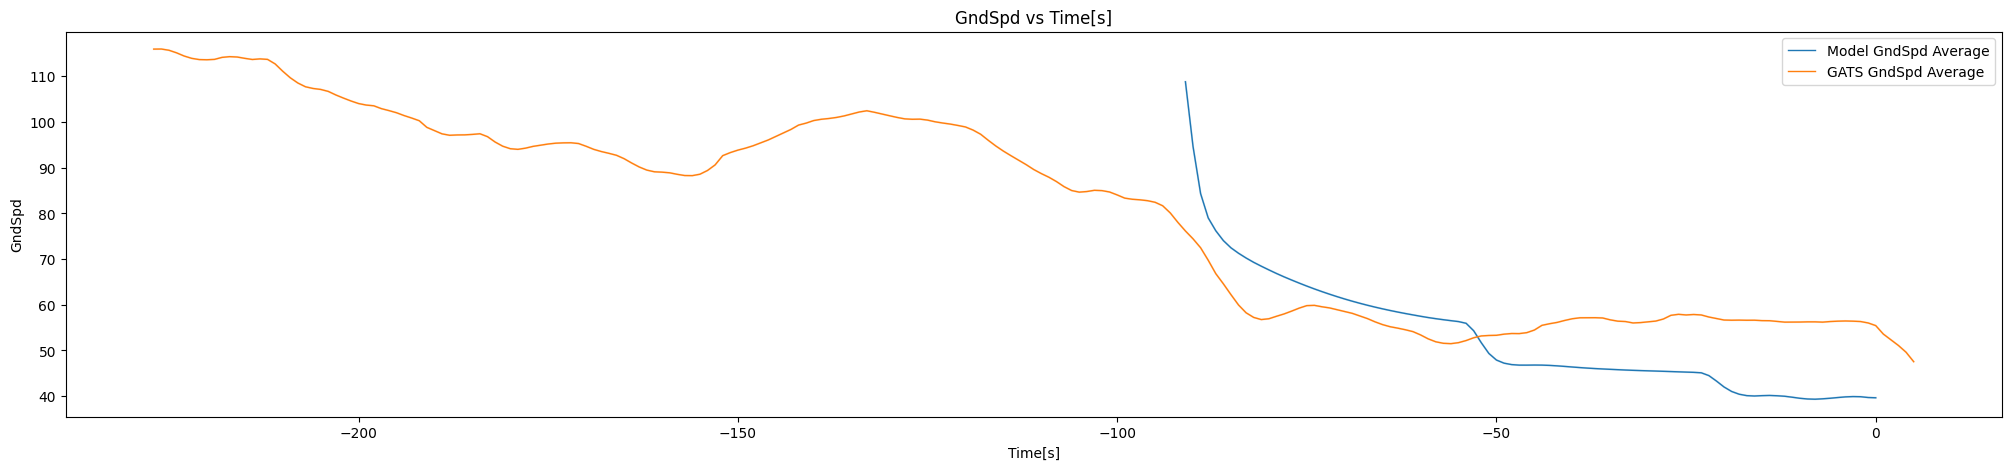

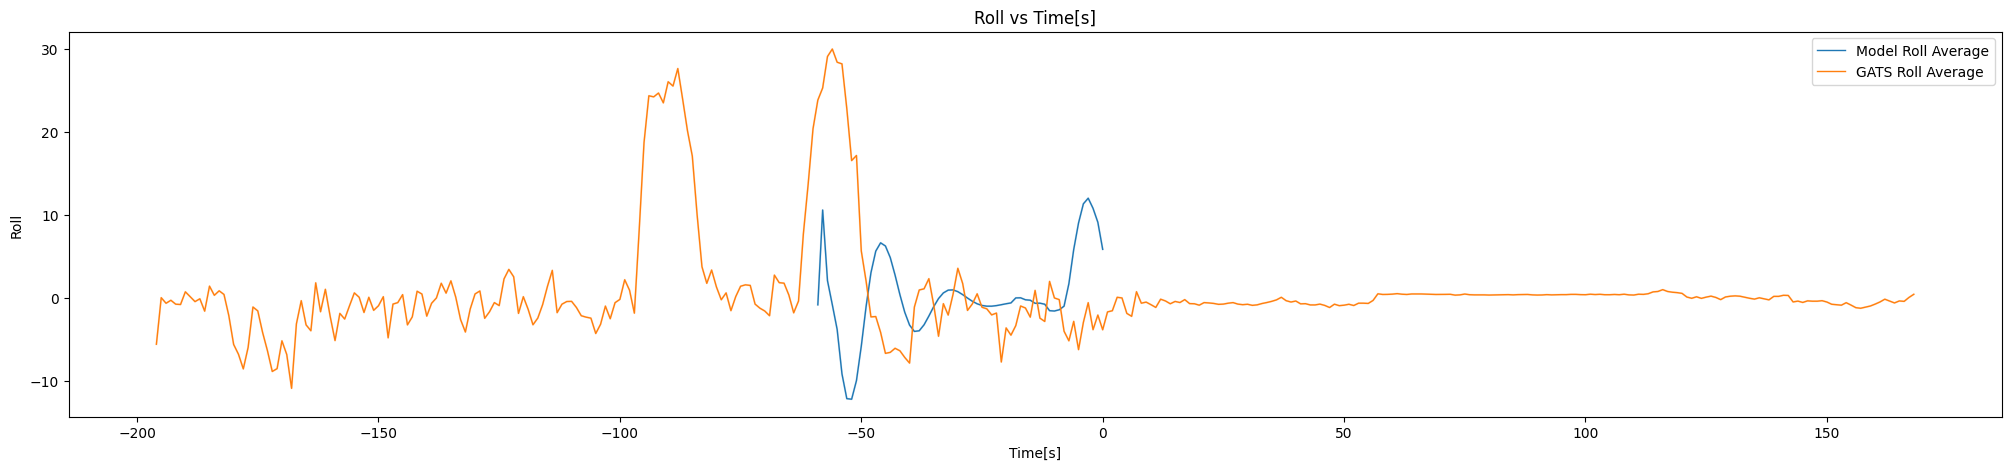

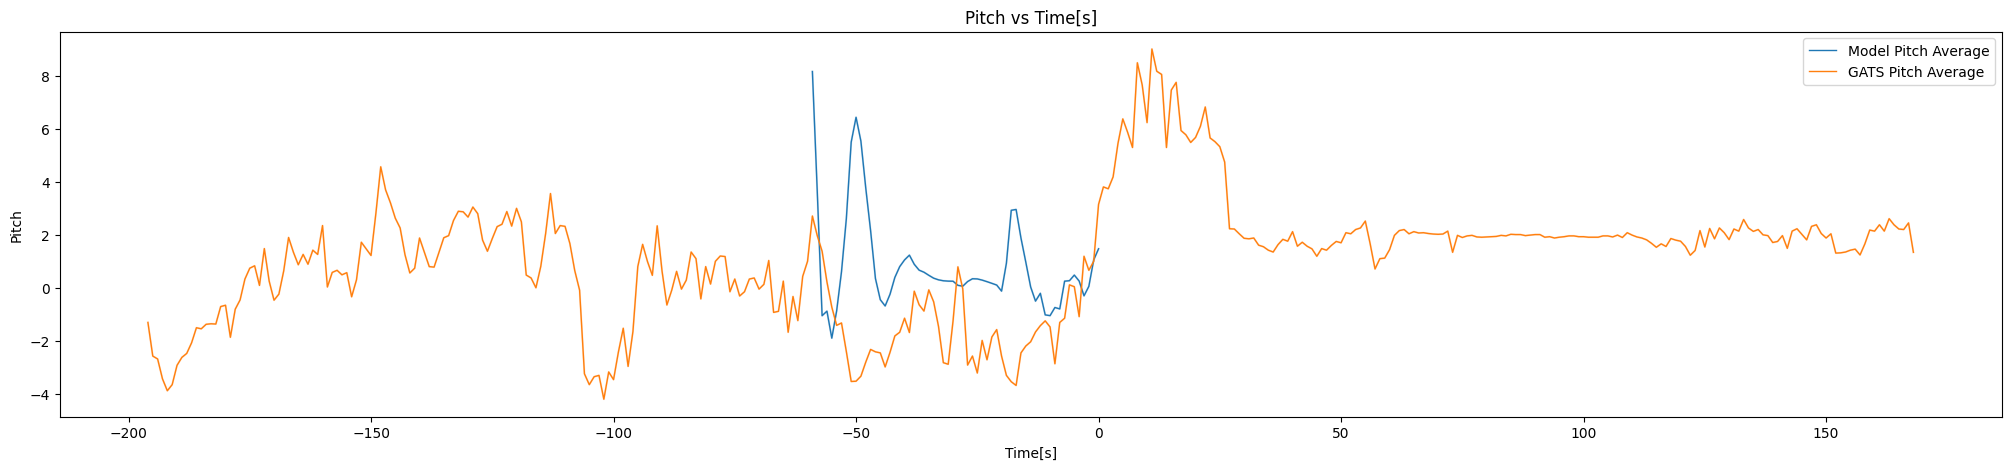

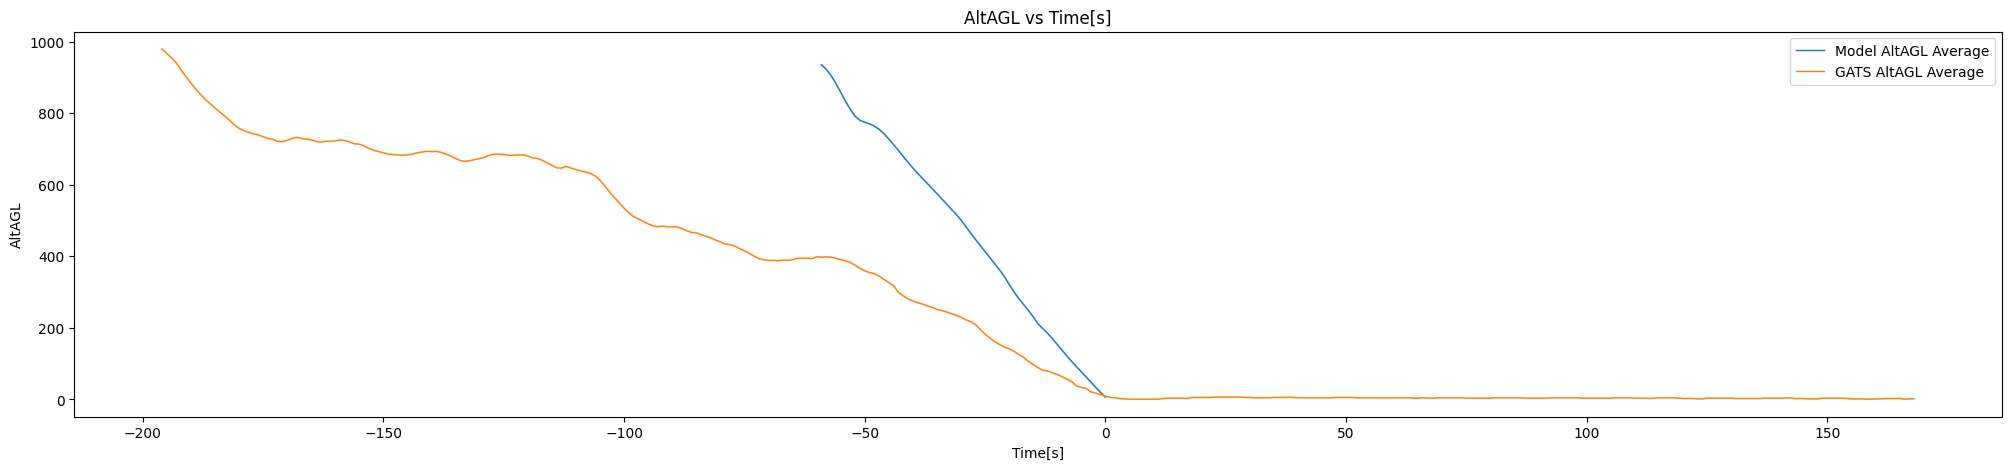

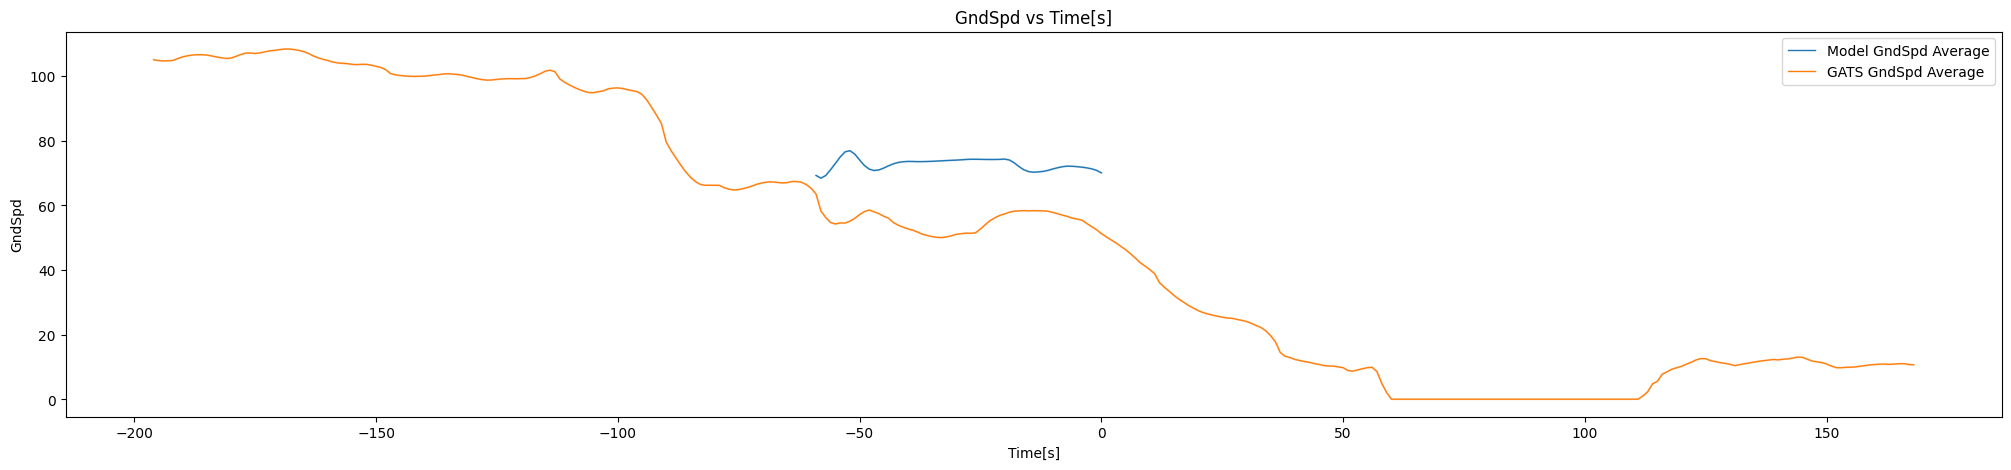

In [7]:
def createDescentArray(dataArray,changeColumn,changeThreshold,minStep,maxStep,alignmentColumn,matchingValue,tolerance,startUpperBound,startLowerBound,stopUpperBound,stopLowerBound):
    descentArray = []
    for df in dataArray:
        descents = identifyChange(df,changeColumn,changeThreshold=changeThreshold,minStep=minStep,maxStep=maxStep,startUpperBound=startUpperBound,startLowerBound=startLowerBound,stopUpperBound=stopUpperBound,stopLowerBound=stopLowerBound)
        # Shift descents so that they line up on their touchdown point
        descents = alignOnCondition(descents,alignmentColumn,matchingValue,tolerance)
        if descents.__len__() > 0:
            descentArray.append(descents)
    return descentArray

def flattenArray(array):
    return [item for sublist in array for item in sublist]

descentArray = []
changeColumn = column.Altitude_AGL
changeThreshold = 800
minStep=1
maxStep=500
startUpperBound = 1000
startLowerBound = 900
stopUpperBound = 0.4
stopLowerBound = 0

alignmentColumn = column.Altitude_AGL
matchingValue= 5
tolerance=5

showAverageLines = True
# for df in dataArray:
#     descents = identifyChange(df,changeColumn,changeThreshold=changeThreshold,minStep=minStep,maxStep=maxStep)
#     # Shift descents so that they line up on their touchdown point
#     descents = alignOnCondition(descents,alignmentColumn,matchingValue,tolerance)
#     if descents.__len__() > 0:
        # descentArray.append(descents)

modelDescentArray = createDescentArray(modelDataArray,changeColumn,changeThreshold,minStep,maxStep,alignmentColumn,matchingValue,tolerance,startUpperBound,startLowerBound,stopUpperBound,stopLowerBound)
gatsDescentArray = createDescentArray(gatsDataArray,changeColumn,changeThreshold,minStep,maxStep,alignmentColumn,matchingValue,tolerance,startUpperBound,startLowerBound,stopUpperBound,stopLowerBound)
modelDescentArrayFlat = flattenArray(modelDescentArray)
gatsDescentArrayFlat = flattenArray(gatsDescentArray)
createExperimentFile(gatsDescentArrayFlat)

# withinGroupPlot(modelDescentArrayFlat,changeColumn,"Time[s]",showAverageLines)
# withinGroupPlot(gatsDescentArrayFlat,changeColumn,"Time[s]",showAverageLines)
betweenGroupPlot([modelDescentArrayFlat,gatsDescentArrayFlat],["Model","GATS"],changeColumn,"Time[s]",True)

for i in range(0,modelDescentArrayFlat.__len__()):
    betweenGroupPlot([[modelDescentArrayFlat[i]],[gatsDescentArrayFlat[i]]],["Model","GATS"],column.Roll,"Time[s]",True)
    betweenGroupPlot([[modelDescentArrayFlat[i]],[gatsDescentArrayFlat[i]]],["Model","GATS"],column.Pitch,"Time[s]",True)
    betweenGroupPlot([[modelDescentArrayFlat[i]],[gatsDescentArrayFlat[i]]],["Model","GATS"],column.Altitude_AGL,"Time[s]",True)
    betweenGroupPlot([[modelDescentArrayFlat[i]],[gatsDescentArrayFlat[i]]],["Model","GATS"],column.Ground_Speed,"Time[s]",True)

